In [29]:
import pandas as pd 
PATH = "data"

sleep = pd.read_csv(f"{PATH}/sleep.csv", skiprows=1, index_col=False).rename(columns={'com.samsung.health.sleep.end_time': 'date'})
sleep = sleep.loc[:, ~sleep.columns.str.contains('^Unnamed')]
sleep['date'] = pd.to_datetime(sleep['date']).dt.normalize()

steps = pd.read_csv(f"{PATH}/steps.csv", skiprows=1, index_col=False)
steps = steps.loc[:, ~steps.columns.str.contains('^Unnamed')]
steps['update_time'] = pd.to_datetime(steps['update_time']).dt.normalize()

# temps = pd.read_csv(f"{PATH}/temperature.csv", skiprows=1, index_col=False).rename(columns={'start_time': 'date'})
# temps = temps.loc[:, ~temps.columns.str.contains('^Unnamed')]
# temps['date'] = pd.to_datetime(sleep['date']).dt.normalize()

In [30]:
sleep[sleep['date'] == '2025-11-17'].iloc[:, 40:50] # total_rem_duration, rem_score, sleep_score, 

,goal_wake_up_time,sleep_cycle,total_light_duration,efficiency,sleep_score,sleep_duration,stage_analyzed_type,total_sleep_time_score,com.samsung.health.sleep.create_sh_ver,com.samsung.health.sleep.start_time
282,25200000.0,3.0,182.0,96.0,41.0,343.0,2.0,10.0,63060051.0,2025-11-16 23:15:00.000


In [10]:
sleep['date'] = pd.to_datetime(sleep['date']).dt.normalize()
sleep = sleep[sleep['date'] > pd.to_datetime('2024-10-01')]
sleep[['sleep_efficiency_with_latency', 'sleep_latency', 'sleep_cycle', 'sleep_score', 'sleep_duration',
       'date']]
sleep.groupby('date')['date'].count().sort_values(ascending=False)

date
2025-09-16    2
2025-06-20    2
2025-02-19    2
2025-10-27    2
2025-09-13    2
             ..
2025-03-10    1
2025-03-12    1
2025-03-13    1
2025-03-14    1
2025-11-17    1
Name: date, Length: 255, dtype: int64

In [4]:
steps.groupby('update_time')['update_time'].count().sort_values(ascending=False)

update_time
2025-10-13    6
2025-04-16    6
2025-02-25    5
2025-06-12    5
2024-12-05    5
             ..
2025-07-20    1
2023-12-08    1
2024-06-29    1
2025-03-24    1
2025-01-20    1
Name: update_time, Length: 2247, dtype: int64

In [12]:
daily_steps = steps[steps['update_time'] > pd.to_datetime('2024-10-01')].groupby('update_time')['count'].max().reset_index()
daily_steps

,update_time,count
0,2024-10-02,7231
1,2024-10-03,7178
2,2024-10-04,8088
3,2024-10-05,12631
4,2024-10-06,1471
...,...,...
406,2025-11-13,11926
407,2025-11-14,10598
408,2025-11-15,12477
409,2025-11-16,603


In [11]:
sleep[sleep['date'] == pd.to_datetime('2025-09-16')][['sleep_efficiency_with_latency', 'sleep_latency', 'sleep_cycle', 'sleep_score', 'sleep_duration',
       'date']]

,sleep_efficiency_with_latency,sleep_latency,sleep_cycle,sleep_score,sleep_duration,date
239,86.0,1740000.0,4.0,69.0,309.0,2025-09-16
240,88.0,480000.0,1.0,61.0,147.0,2025-09-16


In [14]:
daily_sleep = sleep[sleep['date'] > pd.to_datetime('2024-10-01')].groupby('date')['sleep_duration'].sum().reset_index()
daily_sleep

,date,sleep_duration
0,2024-10-23,0.0
1,2024-10-24,0.0
2,2024-10-25,0.0
3,2024-10-28,0.0
4,2024-11-02,451.0
...,...,...
250,2025-11-11,363.0
251,2025-11-12,391.0
252,2025-11-13,400.0
253,2025-11-14,379.0


In [19]:
daily_sleep['daily_sleep_hours'] = daily_sleep['sleep_duration']/60
daily_sleep = daily_sleep[daily_sleep['sleep_duration'] > 0]

--- Merged DataFrame Tail ---
          date  daily_sleep_hours  join_date  count
219 2025-11-02          11.016667 2025-11-02  18394
220 2025-11-03           5.000000 2025-11-03  17589
221 2025-11-06           5.516667 2025-11-06    577
222 2025-11-07           6.333333 2025-11-07   9170
223 2025-11-10           4.633333 2025-11-10     61
224 2025-11-11           6.050000 2025-11-11   9558
225 2025-11-12           6.516667 2025-11-12   9298
226 2025-11-13           6.666667 2025-11-13  11042
227 2025-11-14           6.316667 2025-11-14  11926
228 2025-11-17           5.716667 2025-11-17    603

--- Merged DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229 entries, 0 to 228
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               229 non-null    datetime64[ns]
 1   daily_sleep_hours  229 non-null    float64       
 2   join_date          229 non-null    dat

<Axes: title={'center': 'Sleep Scores vs. Previous Day Steps'}, xlabel='count', ylabel='daily_sleep_hours'>

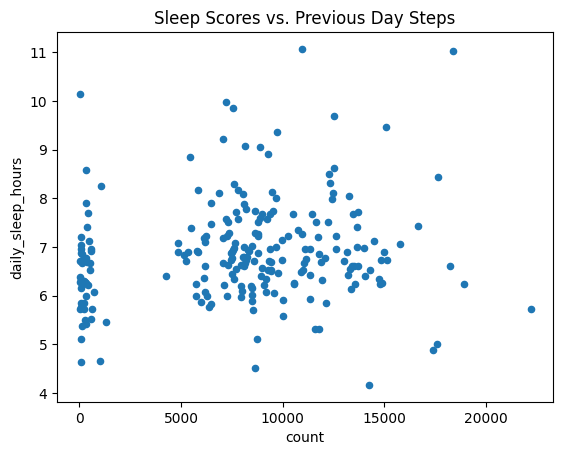

In [25]:
daily_steps['join_date'] = daily_steps['update_time'] + pd.Timedelta(days=1)

merged_df = pd.merge(
    daily_sleep[['date', 'daily_sleep_hours']], 
    daily_steps[['join_date', 'count']], 
    left_on='date', 
    right_on='join_date', # join_date
    how='inner'
)

print("--- Merged DataFrame Tail ---")
print(merged_df.tail(10))

print("\n--- Merged DataFrame Info ---")
merged_df.info()

final_df = merged_df.dropna()

final_df.plot(
    kind='scatter', 
    x='count', # steps
    y='daily_sleep_hours', # sleep
    title='Sleep Scores vs. Previous Day Steps'
)

# efficiency - daily_sleep_hours
# efficiency _ daily_steps

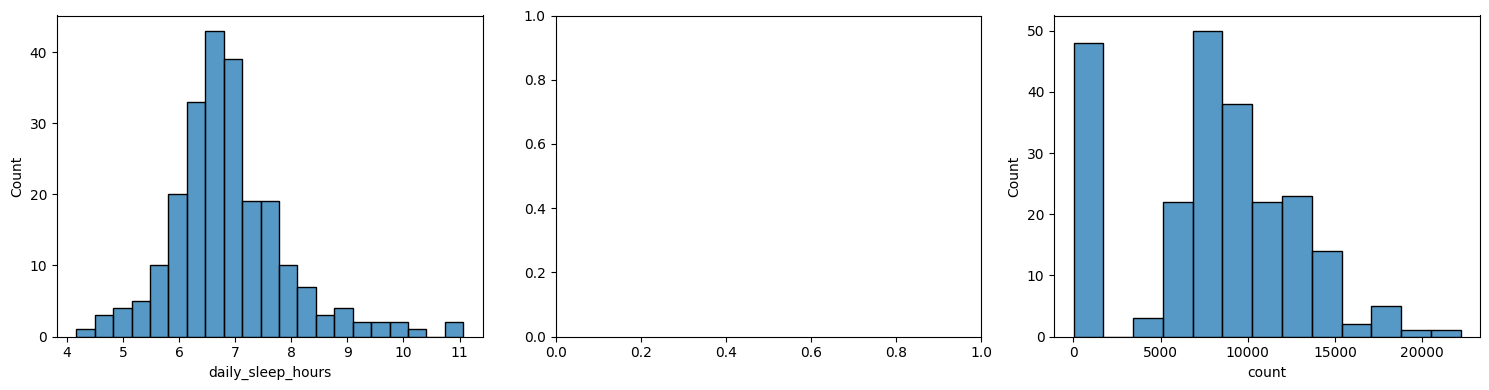

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data=final_df, x='daily_sleep_hours', ax=axes[0])
# sns.histplot(data=final_df, x='efficiency', ax=axes[1])
sns.histplot(data=final_df, x='count', ax=axes[2])

plt.tight_layout()
plt.show()

In [78]:
final_df[final_df['daily_sleep_hours'] < 4] 

,date_x,daily_sleep_hours,efficiency,daily_steps,join_date,date_y
19,2024-11-02,3.666667,60.0,7312,2024-11-02,2024-11-01
20,2024-11-02,3.850000,49.0,7312,2024-11-02,2024-11-01
23,2024-11-04,1.116667,45.0,5733,2024-11-04,2024-11-03
40,2024-11-20,1.666667,54.0,11576,2024-11-20,2024-11-19
41,2024-11-21,1.333333,47.0,8587,2024-11-21,2024-11-20
42,2024-11-21,3.983333,65.0,8587,2024-11-21,2024-11-20
86,2025-01-14,3.116667,56.0,5827,2025-01-14,2025-01-13
182,2025-06-20,1.383333,52.0,7356,2025-06-20,2025-06-19
210,2025-08-04,3.966667,48.0,279,2025-08-04,2025-08-03
211,2025-08-04,2.883333,59.0,279,2025-08-04,2025-08-03


In [25]:
sleep['sleep_duration'] = sleep['sleep_duration'] / 60
sleep[sleep['sleep_duration'] < 2][['sleep_duration', 'date']]

,sleep_duration,date
19,0.061111,2024-11-02
20,0.064167,2024-11-02
21,0.147500,2024-11-03
22,0.081389,2024-11-04
23,0.018611,2024-11-04
...,...,...
278,0.100833,2025-11-11
279,0.108611,2025-11-12
280,0.111111,2025-11-13
281,0.105278,2025-11-14


DATA SUMMARY
        rem_ratio         count
count  229.000000    229.000000
mean     0.243533  18807.938865
std      0.046820  14693.139437
min      0.081433     36.000000
25%      0.213043   7273.000000
50%      0.246696  17324.000000
75%      0.277174  27686.000000
max      0.344059  63889.000000

CORRELATION
           rem_ratio     count
rem_ratio   1.000000  0.232827
count       0.232827  1.000000


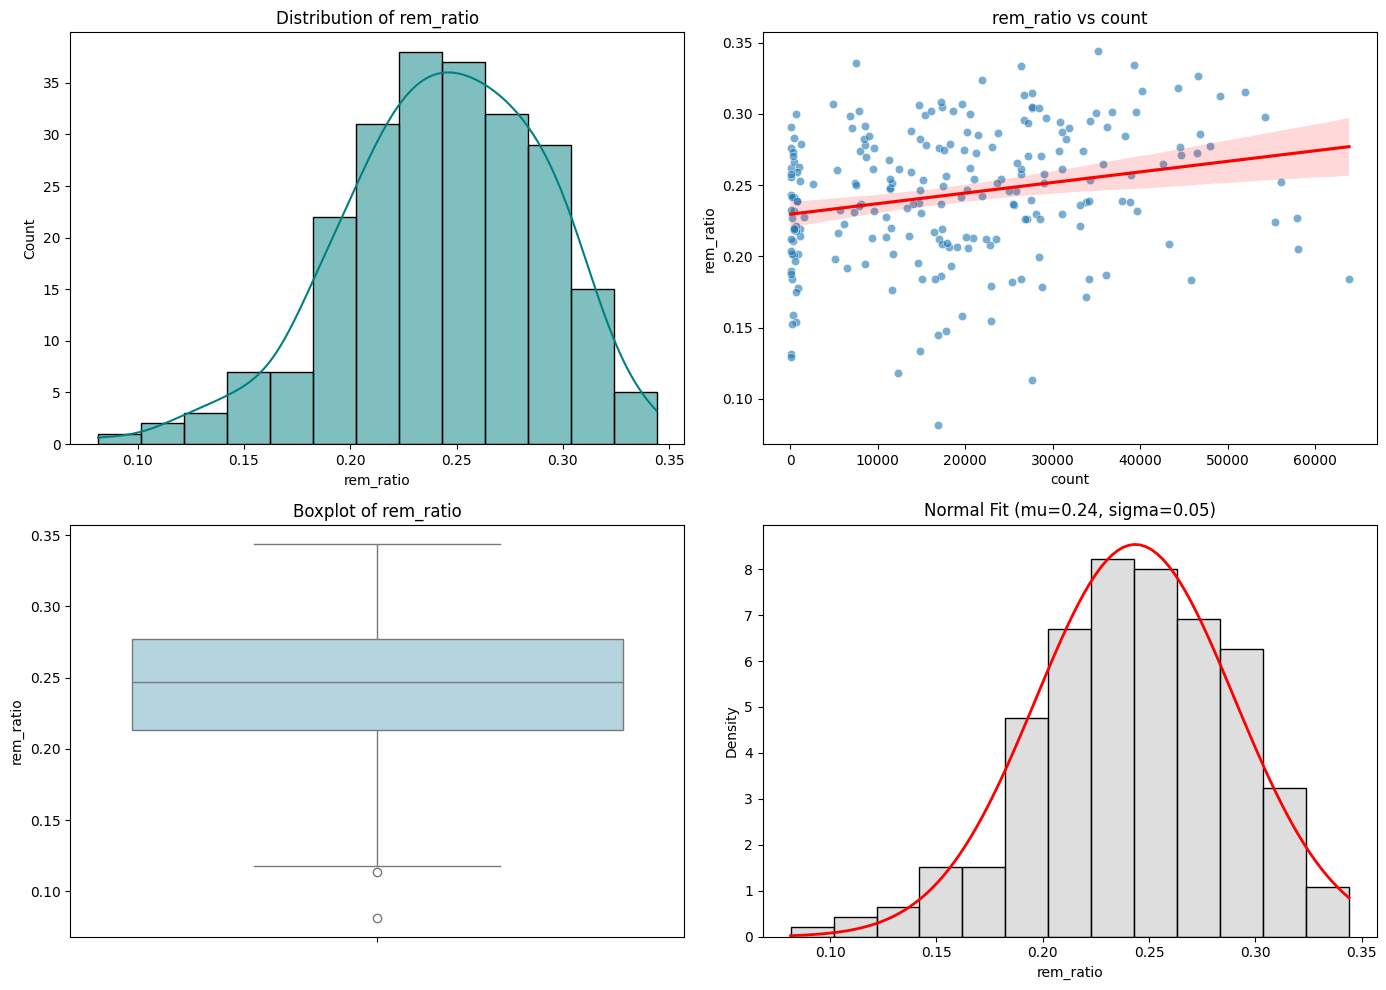


KS TEST (Normality) for rem_ratio: Statistic=0.0465, P-Value=0.6866

T-TEST (Benchmark = 0.25): Statistic=-2.0901, P-Value=0.0377

REGRESSION RESULTS
                            OLS Regression Results                            
Dep. Variable:              rem_ratio   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     13.01
Date:                Sun, 14 Dec 2025   Prob (F-statistic):           0.000381
Time:                        00:18:02   Log-Likelihood:                 383.01
No. Observations:                 229   AIC:                            -762.0
Df Residuals:                     227   BIC:                            -755.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|     

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

PATH = "data"
TARGET_COL = 'rem_ratio' 
PREDICTOR_COL = 'count'
HYPOTHESIS_BENCHMARK = 0.25

sleep = pd.read_csv(f"{PATH}/sleep.csv", skiprows=1, index_col=False, on_bad_lines='skip')
sleep = sleep.rename(columns={'com.samsung.health.sleep.end_time': 'date'})
sleep = sleep.loc[:, ~sleep.columns.str.contains('^Unnamed')]
sleep['date'] = pd.to_datetime(sleep['date']).dt.normalize()
sleep = sleep[(sleep['date'] > pd.to_datetime('2024-10-01')) & (sleep['sleep_duration'] > 0)] 

# cols_to_numeric = ['sleep_duration', 'physical_recovery', 'sleep_score', 'total_rem_duration', 'rem_score']
# for col in cols_to_numeric:
#     if col in sleep.columns:
#         sleep[col] = pd.to_numeric(sleep[col], errors='coerce')

daily_sums = sleep.groupby('date')[['sleep_duration', 'total_rem_duration']].sum().reset_index()
daily_sums['daily_sleep_hours'] = daily_sums['sleep_duration'] / 60
daily_sums['daily_rem_hours'] = daily_sums['total_rem_duration'] / 60
daily_sums['rem_ratio'] = daily_sums['daily_rem_hours'] / daily_sums['daily_sleep_hours']

# daily_max = sleep.groupby('date')[['physical_recovery', 'sleep_score']].max().reset_index()

# daily_sleep = pd.merge(daily_sums, daily_max, on='date')

steps = pd.read_csv(f"{PATH}/steps.csv", skiprows=1, index_col=False, on_bad_lines='skip')
steps = steps.loc[:, ~steps.columns.str.contains('^Unnamed')]
steps['update_time'] = pd.to_datetime(steps['update_time']).dt.normalize()

daily_steps = steps.groupby('update_time')['count'].sum().reset_index()
daily_steps['join_date'] = daily_steps['update_time'] + pd.Timedelta(days=1)

merged_df = pd.merge(
    daily_sums, 
    daily_steps[['join_date', 'count']], 
    left_on='date', 
    right_on='join_date',
    how='inner'
)

df = merged_df.dropna(subset=[TARGET_COL, PREDICTOR_COL])

print("DATA SUMMARY")
print(df[[TARGET_COL, PREDICTOR_COL]].describe())

print("\nCORRELATION")
print(df[[TARGET_COL, PREDICTOR_COL]].corr())

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.histplot(df[TARGET_COL], kde=True, color='teal')
plt.title(f'Distribution of {TARGET_COL}')

plt.subplot(2, 2, 2)
sns.scatterplot(x=df[PREDICTOR_COL], y=df[TARGET_COL], alpha=0.6)
sns.regplot(x=df[PREDICTOR_COL], y=df[TARGET_COL], scatter=False, color='red')
plt.title(f'{TARGET_COL} vs {PREDICTOR_COL}')

plt.subplot(2, 2, 3)
sns.boxplot(y=df[TARGET_COL], color='lightblue')
plt.title(f'Boxplot of {TARGET_COL}')

plt.subplot(2, 2, 4)
data = df[TARGET_COL]
mu, sigma = stats.norm.fit(data)
x_range = np.linspace(min(data), max(data), 100)
sns.histplot(data, stat="density", color='lightgray')
plt.plot(x_range, stats.norm.pdf(x_range, mu, sigma), 'r-', linewidth=2)
plt.title(f'Normal Fit (mu={mu:.2f}, sigma={sigma:.2f})')

plt.tight_layout()
plt.show()

ks_stat, ks_p = stats.kstest(data, 'norm', args=(mu, sigma))
print(f"\nKS TEST (Normality) for {TARGET_COL}: Statistic={ks_stat:.4f}, P-Value={ks_p:.4f}")

t_stat, t_p = stats.ttest_1samp(data, HYPOTHESIS_BENCHMARK)
print(f"\nT-TEST (Benchmark = {HYPOTHESIS_BENCHMARK}): Statistic={t_stat:.4f}, P-Value={t_p:.4f}")

X = sm.add_constant(df[PREDICTOR_COL])
Y = df[TARGET_COL]
model = sm.OLS(Y, X).fit()

print("\nREGRESSION RESULTS")
print(model.summary())

In [55]:
sleep = pd.read_csv(f"{PATH}/sleep12.csv", skiprows=1, index_col=False, on_bad_lines='skip')
sleep

,total_sleep_time_weight,original_efficiency,mental_recovery,wake_score,factor_01,factor_02,factor_03,factor_04,factor_05,factor_06,...,com.samsung.health.sleep.update_time,com.samsung.health.sleep.create_time,com.samsung.health.sleep.client_data_id,com.samsung.health.sleep.client_data_ver,com.samsung.health.sleep.time_offset,com.samsung.health.sleep.deviceuuid,com.samsung.health.sleep.comment,com.samsung.health.sleep.pkg_name,com.samsung.health.sleep.end_time,com.samsung.health.sleep.datauuid
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2021-08-07 16:27:14.981,2021-08-07 16:27:14.981,NaN,NaN,UTC+0300,bWj3B5w0Pp,NaN,com.sec.android.app.shealth,2021-08-07 10:50:00.000,3402b213-2707-4323-befa-5429ca1742ef
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2021-08-29 13:21:08.598,2021-08-29 13:21:08.598,NaN,NaN,UTC+0300,bWj3B5w0Pp,NaN,com.sec.android.app.shealth,2021-08-29 09:50:00.000,75e086df-26f4-43cf-83e0-b0b56c00f879
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2024-03-05 20:45:54.990,2024-03-05 20:45:54.990,NaN,NaN,UTC+0300,bWj3B5w0Pp,NaN,com.sec.android.app.shealth,2024-03-05 08:40:00.000,00ec8101-af56-4443-a850-25ae0e38b3cd
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2024-05-24 16:44:19.309,2024-05-24 16:44:19.309,NaN,NaN,UTC+0300,bWj3B5w0Pp,NaN,com.sec.android.app.shealth,2024-05-24 05:40:00.000,05ea9269-388f-47c5-9122-91f592cf091f
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2024-05-25 15:27:40.553,2024-05-25 15:27:40.553,NaN,NaN,UTC+0300,bWj3B5w0Pp,NaN,com.sec.android.app.shealth,2024-05-25 07:40:00.000,73def407-e0db-45be-b05f-d3a40a2a9155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,34.0,NaN,87.0,6.0,73.0,136.0,5.0,1.0,18.0,430.0,...,2025-12-08 05:02:50.730,2025-12-08 04:55:33.676,NaN,NaN,UTC+0300,IChoSlfqVi,NaN,com.sec.android.app.shealth,2025-12-08 04:29:00.000,a201f7a5-0d52-4646-82a7-423f008554b4
298,34.0,NaN,93.0,6.0,19.0,92.0,2.0,2.0,13.0,370.0,...,2025-12-09 04:07:25.329,2025-12-09 04:07:17.198,NaN,NaN,UTC+0300,IChoSlfqVi,NaN,com.sec.android.app.shealth,2025-12-09 04:07:00.000,c88ab999-1a33-4b0b-8623-cdd785b96aa7
299,34.0,NaN,93.0,6.0,64.0,115.0,9.0,4.0,21.0,412.0,...,2025-12-10 04:25:58.146,2025-12-10 04:25:35.988,NaN,NaN,UTC+0300,IChoSlfqVi,NaN,com.sec.android.app.shealth,2025-12-10 04:25:00.000,5db51cf8-0e61-4868-9239-51f842caa3c0
300,34.0,NaN,93.0,6.0,37.0,119.0,1.0,3.0,12.0,404.0,...,2025-12-11 04:35:36.330,2025-12-11 04:35:11.250,NaN,NaN,UTC+0300,IChoSlfqVi,NaN,com.sec.android.app.shealth,2025-12-11 04:35:00.000,91241a68-5697-4c84-9679-caad81b7e91e


--- DATA SUMMARY ---
       daily_rem_hours         count  sleep_duration
count       247.000000    247.000000      247.000000
mean          1.702294  19269.400810      413.542510
std           0.472170  14991.369385       62.893939
min           0.416667     36.000000      250.000000
25%           1.416667   7544.500000      376.000000
50%           1.700000  17401.000000      405.000000
75%           1.991667  28448.000000      437.000000
max           3.616667  63889.000000      664.000000

--- SHAPE STATISTICS ---
Skewness: 0.2656
Kurtosis: 0.7392

--- CORRELATION ---
                 daily_rem_hours     count
daily_rem_hours         1.000000  0.263934
count                   0.263934  1.000000

--- PARAMETER ESTIMATION (daily_rem_hours) ---
MLE (stats.norm.fit): mu=1.7023, sigma=0.4712
MoM (Calculated)    : mu=1.7023, sigma=0.4712
Bayesian Estimate   : mu=1.7016 (Prior: mu=1.5, tau=0.5)


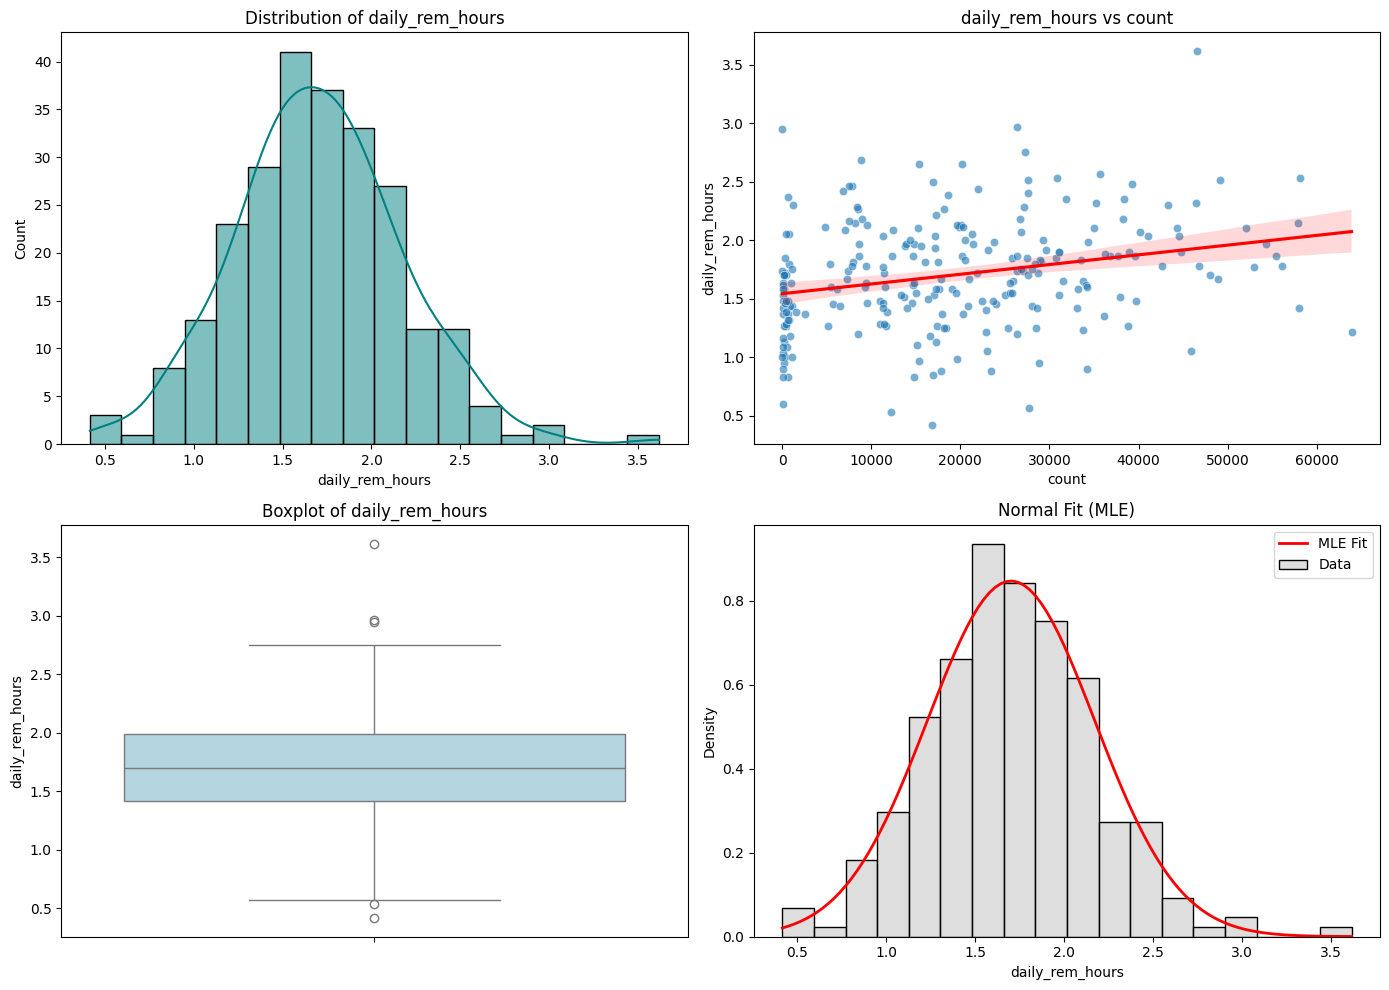


--- GOODNESS OF FIT (KS TEST) ---
Statistic=0.0438, P-Value=0.7143

--- HYPOTHESIS TESTING (Benchmark = 1.5) ---
Result: Data looks Normal (p > 0.05). Using Parametric Test (T-Test).
One-Sample T-Test: Statistic=6.7334, P-Value=0.0000

--- REGRESSION RESULTS ---
                            OLS Regression Results                            
Dep. Variable:        daily_rem_hours   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     18.34
Date:                Sun, 14 Dec 2025   Prob (F-statistic):           2.65e-05
Time:                        18:00:04   Log-Likelihood:                -155.71
No. Observations:                 247   AIC:                             315.4
Df Residuals:                     245   BIC:                             322.4
Df Model:                           1                                         
Covariance Type:         

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

# --- CONFIGURATION ---
PATH = "data"
TARGET_COL = 'daily_rem_hours' 
SLEEP_COL = 'sleep_duration'
PREDICTOR_COL = 'count'
HYPOTHESIS_BENCHMARK = 1.5

# --- 1. DATA COLLECTION & PREPROCESSING ---
sleep = pd.read_csv(f"{PATH}/sleep12.csv", skiprows=1, index_col=False, on_bad_lines='skip')
sleep = sleep.rename(columns={'com.samsung.health.sleep.end_time': 'date'})
sleep = sleep.loc[:, ~sleep.columns.str.contains('^Unnamed')]
sleep['date'] = pd.to_datetime(sleep['date']).dt.normalize()
# sleep['sleep_duration'] = sleep['sleep_duration'] / 60
# Filtering for valid dates and durations
sleep = sleep[(sleep['date'] > pd.to_datetime('2024-10-01')) & (sleep['sleep_duration'] > 0)] 

daily_sums = sleep.groupby('date')[['sleep_duration', 'total_rem_duration']].sum().reset_index()
daily_sums['daily_sleep_hours'] = daily_sums['sleep_duration'] / 60
daily_sums['daily_rem_hours'] = daily_sums['total_rem_duration'] / 60

steps = pd.read_csv(f"{PATH}/steps12.csv", skiprows=2, index_col=False, on_bad_lines='skip')
steps = steps.loc[:, ~steps.columns.str.contains('^Unnamed')]
steps['update_time'] = pd.to_datetime(steps['update_time']).dt.normalize()

daily_steps = steps.groupby('update_time')['count'].sum().reset_index()
# Shifting steps by 1 day (assumes steps today affect sleep tonight/tomorrow)
daily_steps['join_date'] = daily_steps['update_time'] + pd.Timedelta(days=1)

merged_df = pd.merge(
    daily_sums, 
    daily_steps[['join_date', 'count']], 
    left_on='date', 
    right_on='join_date',
    how='inner'
)

df = merged_df.dropna(subset=[TARGET_COL, PREDICTOR_COL])
data = df[TARGET_COL]

# --- 2. EXPLORATORY DATA ANALYSIS (EDA) ---
print("--- DATA SUMMARY ---")
print(df[[TARGET_COL, PREDICTOR_COL, SLEEP_COL]].describe())

# Added: Skewness and Kurtosis [cite: 20]
skewness = stats.skew(data)
kurt = stats.kurtosis(data)
print(f"\n--- SHAPE STATISTICS ---")
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurt:.4f}")

print("\n--- CORRELATION ---")
print(df[[TARGET_COL, PREDICTOR_COL]].corr())

# Visualization
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.histplot(df[TARGET_COL], kde=True, color='teal')
plt.title(f'Distribution of {TARGET_COL}')

plt.subplot(2, 2, 2)
sns.scatterplot(x=df[PREDICTOR_COL], y=df[TARGET_COL], alpha=0.6)
sns.regplot(x=df[PREDICTOR_COL], y=df[TARGET_COL], scatter=False, color='red')
plt.title(f'{TARGET_COL} vs {PREDICTOR_COL}')

plt.subplot(2, 2, 3)
sns.boxplot(y=df[TARGET_COL], color='lightblue')
plt.title(f'Boxplot of {TARGET_COL}')

# --- 3. PARAMETER ESTIMATION ---
# A) Maximum Likelihood Estimation (MLE) [cite: 26]
mu_mle, sigma_mle = stats.norm.fit(data)

# B) Method of Moments (MoM) [cite: 27]
# For Normal dist, MoM is simply Sample Mean and Population Std (ddof=0)
mu_mom = data.mean()
sigma_mom = data.std(ddof=0)

# C) Bayesian Estimation (Conjugate Prior) [cite: 28]
# Prior Belief: We expect ~1.5 hours REM (mu_0) with some uncertainty (tau)
mu_0 = 1.5      
tau = 0.5       
n = len(data)

# Bayesian Update for Mean (assuming known variance sigma_mle^2 for simplicity)
var_data = sigma_mle**2
var_prior = tau**2
weight_prior = var_data / (n * var_prior + var_data)
weight_data = (n * var_prior) / (n * var_prior + var_data)
mu_bayes = weight_prior * mu_0 + weight_data * data.mean()

print(f"\n--- PARAMETER ESTIMATION ({TARGET_COL}) ---")
print(f"MLE (stats.norm.fit): mu={mu_mle:.4f}, sigma={sigma_mle:.4f}")
print(f"MoM (Calculated)    : mu={mu_mom:.4f}, sigma={sigma_mom:.4f}")
print(f"Bayesian Estimate   : mu={mu_bayes:.4f} (Prior: mu={mu_0}, tau={tau})")

# Plotting the fit
plt.subplot(2, 2, 4)
x_range = np.linspace(min(data), max(data), 100)
sns.histplot(data, stat="density", color='lightgray', label='Data')
plt.plot(x_range, stats.norm.pdf(x_range, mu_mle, sigma_mle), 'r-', linewidth=2, label=f'MLE Fit')
plt.legend()
plt.title(f'Normal Fit (MLE)')

plt.tight_layout()
plt.show()

# --- 4. GOODNESS OF FIT & HYPOTHESIS TESTING ---
# KS Test [cite: 33]
ks_stat, ks_p = stats.kstest(data, 'norm', args=(mu_mle, sigma_mle))
print(f"\n--- GOODNESS OF FIT (KS TEST) ---")
print(f"Statistic={ks_stat:.4f}, P-Value={ks_p:.4f}")

# Conditional Hypothesis Testing 
print(f"\n--- HYPOTHESIS TESTING (Benchmark = {HYPOTHESIS_BENCHMARK}) ---")
alpha = 0.05

if ks_p > alpha:
    print(f"Result: Data looks Normal (p > {alpha}). Using Parametric Test (T-Test).")
    t_stat, t_p = stats.ttest_1samp(data, HYPOTHESIS_BENCHMARK)
    print(f"One-Sample T-Test: Statistic={t_stat:.4f}, P-Value={t_p:.4f}")
else:
    print(f"Result: Data does NOT look Normal (p < {alpha}). Using Nonparametric Test (Wilcoxon).")
    # Wilcoxon Signed-Rank Test is the nonparametric alternative to one-sample t-test
    w_stat, w_p = stats.wilcoxon(data - HYPOTHESIS_BENCHMARK)
    print(f"Wilcoxon Signed-Rank Test: Statistic={w_stat:.4f}, P-Value={w_p:.4f}")

# --- 5. REGRESSION ANALYSIS ---
# [cite: 37]
X = sm.add_constant(df[PREDICTOR_COL])
Y = df[TARGET_COL]
model = sm.OLS(Y, X).fit()

print("\n--- REGRESSION RESULTS ---")
print(model.summary())

In [65]:
# --- VISUALIZATION & SAVING INDIVIDUALLY ---

# 1. Histogram with MLE Fit
plt.figure(figsize=(8, 6))
sns.histplot(df[TARGET_COL], kde=True, color='teal', label='Data', stat='density')
x_range = np.linspace(min(data), max(data), 100)
plt.plot(x_range, stats.norm.pdf(x_range, mu_mle, sigma_mle), 'r-', linewidth=2, label='MLE Normal Fit')
plt.title(f'Distribution of REM Sleep Hours')
plt.xlabel('Daily REM Hours')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('histogram.png', dpi=300)
plt.close()
print("Saved histogram.png")

# 2. Scatter Plot with Regression Line
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df[PREDICTOR_COL], y=df[TARGET_COL], alpha=0.6, color='blue')
sns.regplot(x=df[PREDICTOR_COL], y=df[TARGET_COL], scatter=False, color='red', label='Regression Line')
plt.title(f'REM Sleep vs. Daily Steps')
plt.xlabel('Daily Step Count')
plt.ylabel('REM Sleep (Hours)')
plt.legend()
plt.tight_layout()
plt.savefig('scatter.png', dpi=300)
plt.close()
print("Saved scatter.png")

# 3. Boxplot
plt.figure(figsize=(6, 6))
sns.boxplot(y=df[TARGET_COL], color='lightblue')
plt.title(f'Boxplot of REM Sleep')
plt.ylabel('REM Sleep (Hours)')
plt.tight_layout()
plt.savefig('boxplot.png', dpi=300)
plt.close()
print("Saved boxplot.png")

Saved histogram.png
Saved scatter.png
Saved boxplot.png


In [72]:
daily_sums

,date,sleep_duration,total_rem_duration,daily_sleep_hours,daily_rem_hours
0,2024-11-02,451.0,88.0,7.516667,1.466667
1,2024-11-03,531.0,159.0,8.850000,2.650000
2,2024-11-04,360.0,77.0,6.000000,1.283333
3,2024-11-05,433.0,92.0,7.216667,1.533333
4,2024-11-06,396.0,126.0,6.600000,2.100000
...,...,...,...,...,...
243,2025-12-08,430.0,79.0,7.166667,1.316667
244,2025-12-09,370.0,105.0,6.166667,1.750000
245,2025-12-10,412.0,112.0,6.866667,1.866667
246,2025-12-11,404.0,106.0,6.733333,1.766667


--- STATISTICS BY MONTH ---
           daily_sleep_hours             daily_rem_hours            
                        mean   std count            mean   std count
year_month                                                          
2024-11                 7.30  1.23    29            1.90  0.59    29
2024-12                 7.10  1.12    26            1.72  0.40    26
2025-01                 6.73  1.30    15            1.66  0.56    15
2025-02                 6.81  0.80     8            1.65  0.35     8
2025-03                 7.14  0.54     4            1.98  0.30     4
2025-04                 6.61  0.81    20            1.54  0.38    20
2025-05                 6.58  0.84    19            1.47  0.44    19
2025-06                 6.84  0.58    18            1.70  0.44    18
2025-07                 6.74  0.51    21            1.75  0.24    21
2025-08                 6.58  1.10    20            1.64  0.53    20
2025-09                 7.30  1.17    18            1.77  0.48    18
2025-1

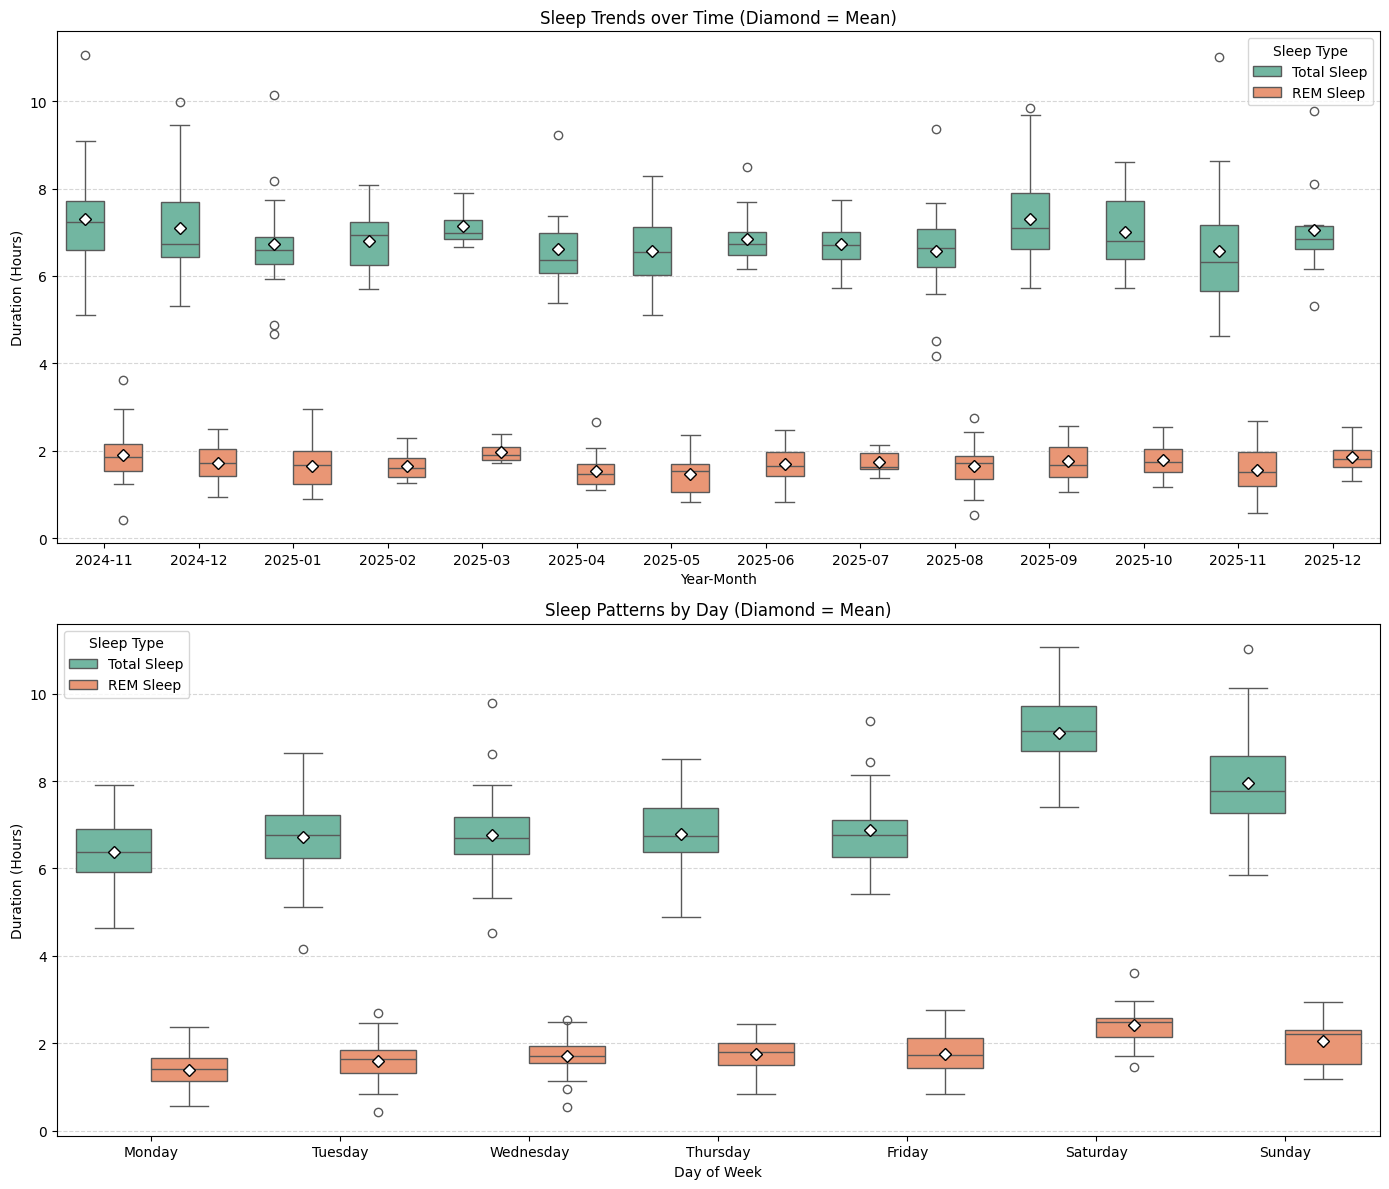

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. PREPARE DATA ---
# (Assuming daily_sums is already created from previous steps)
# Ensure we have the 'year_month' and 'day_name' columns
daily_sums['year_month'] = daily_sums['date'].dt.to_period('M').astype(str)
daily_sums['day_name'] = daily_sums['date'].dt.day_name()
daily_sums = daily_sums.sort_values('date')

# Melt for Plotting
df_melted = daily_sums.melt(
    id_vars=['date', 'year_month', 'day_name'], 
    value_vars=['daily_sleep_hours', 'daily_rem_hours'],
    var_name='Sleep Type', 
    value_name='Duration (Hours)'
)

df_melted['Sleep Type'] = df_melted['Sleep Type'].replace({
    'daily_sleep_hours': 'Total Sleep', 
    'daily_rem_hours': 'REM Sleep'
})

# --- 2. CALCULATE STATISTICS ---
# Group by Month
stats_month = daily_sums.groupby('year_month')[['daily_sleep_hours', 'daily_rem_hours']].agg(['mean', 'std', 'count']).round(2)
print("--- STATISTICS BY MONTH ---")
print(stats_month)

# Group by Weekday
# Reorder index to be Mon-Sun
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

stats_day = daily_sums.groupby('day_name')[['daily_sleep_hours', 'daily_rem_hours']]\
    .agg(['count', 'mean', 'std'])\
    .reindex(day_order)\
    .round(2)

print("\n--- STATISTICS BY WEEKDAY (With Count) ---")
print(stats_day)

# --- 3. VISUALIZATION WITH MEAN MARKERS ---
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# PLOT 1: Chronological
sns.boxplot(data=df_melted, x='year_month', y='Duration (Hours)', hue='Sleep Type', 
            palette="Set2", ax=axes[0], showmeans=True, 
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":6})
axes[0].set_title('Sleep Trends over Time (Diamond = Mean)')
axes[0].set_xlabel('Year-Month')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# PLOT 2: Weekday Patterns
sns.boxplot(data=df_melted, x='day_name', y='Duration (Hours)', hue='Sleep Type', 
            order=day_order, palette="Set2", ax=axes[1], showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":6})
axes[1].set_title('Sleep Patterns by Day (Diamond = Mean)')
axes[1].set_xlabel('Day of Week')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('temporal_stats.png', dpi=300)
plt.show()


--- STEP STATISTICS BY WEEKDAY ---
           count     mean      std
day_name                          
Monday        62  17549.0   9536.0
Tuesday       62  23461.0  13449.0
Wednesday     63  25490.0  15329.0
Thursday      63  23231.0  11722.0
Friday        63  25518.0  14090.0
Saturday      62  12569.0  11480.0
Sunday        61   5052.0  10533.0


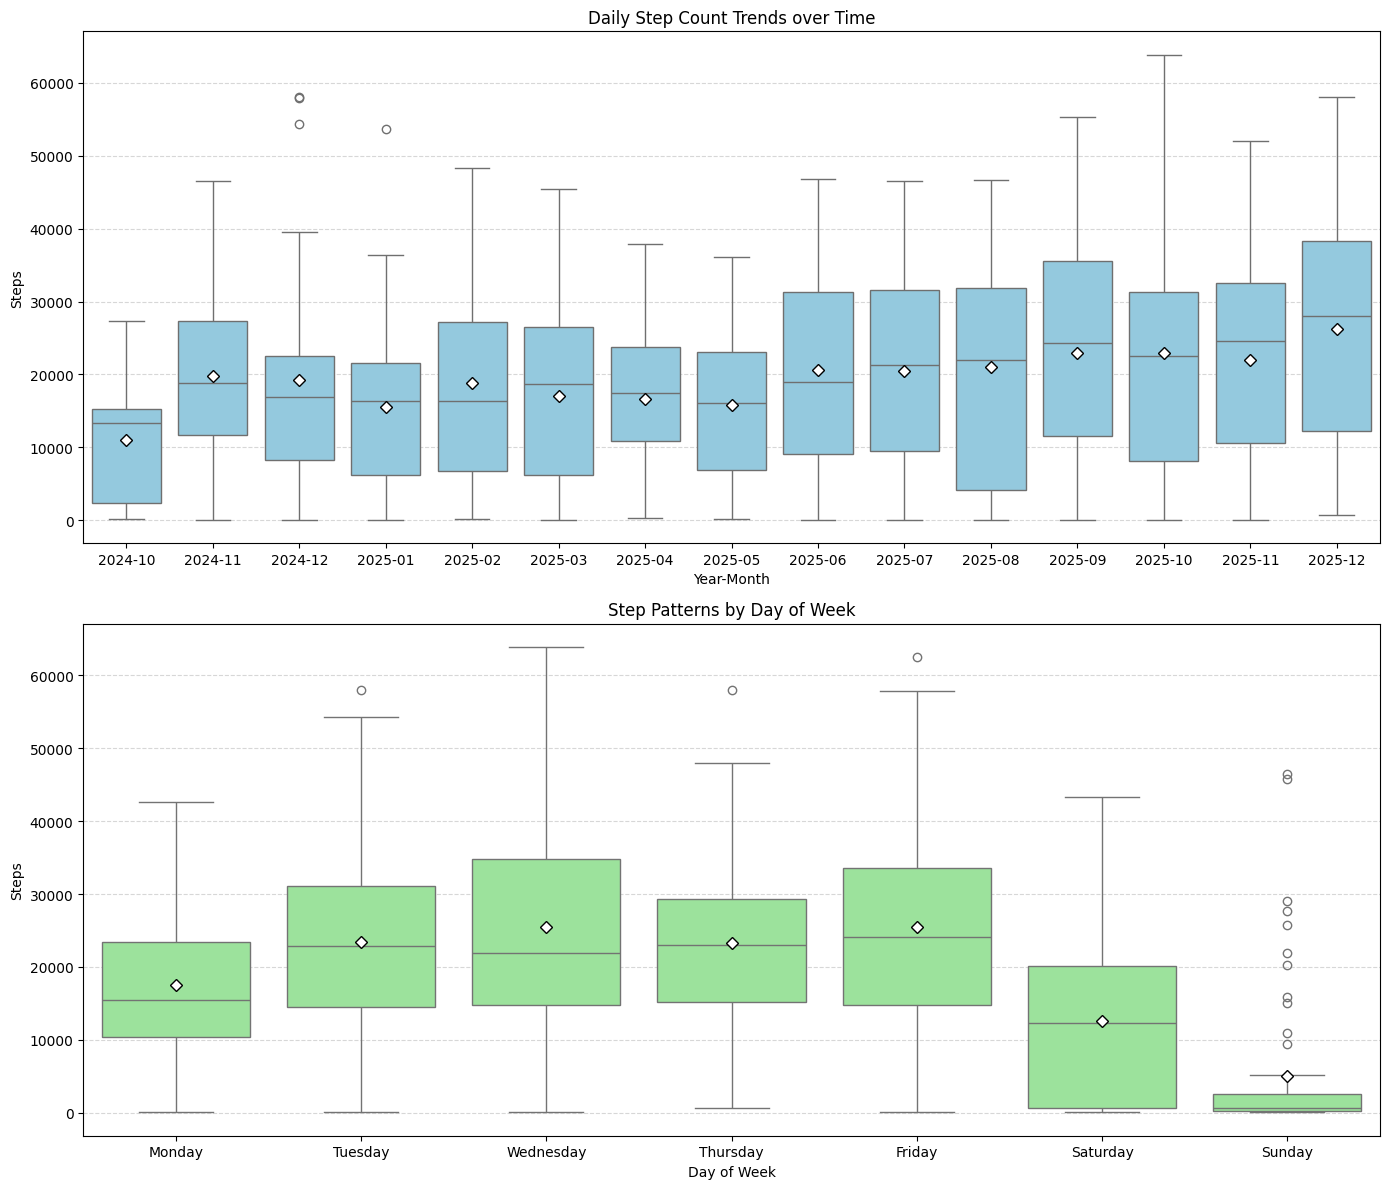

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. LOAD & PROCESS STEP DATA ---
PATH = "data"
# Load steps (skiprows=2 based on your initial script)
steps = pd.read_csv(f"{PATH}/steps12.csv", skiprows=2, index_col=False, on_bad_lines='skip')
steps = steps.loc[:, ~steps.columns.str.contains('^Unnamed')]
steps['update_time'] = pd.to_datetime(steps['update_time']).dt.normalize()

# Filter for the same time period as sleep (from Oct 2024)
steps = steps[steps['update_time'] > pd.to_datetime('2024-10-01')]

# Group by Date (Daily Total Steps)
daily_steps = steps.groupby('update_time')['count'].sum().reset_index()

# Create Time Features
daily_steps['year_month'] = daily_steps['update_time'].dt.to_period('M').astype(str)
daily_steps['day_name'] = daily_steps['update_time'].dt.day_name()
daily_steps = daily_steps.sort_values('update_time')

# --- 2. CALCULATE STATISTICS ---
# Group by Weekday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
stats_steps = daily_steps.groupby('day_name')['count']\
    .agg(['count', 'mean', 'std'])\
    .reindex(day_order)\
    .round(0) # Round steps to nearest whole number

print("\n--- STEP STATISTICS BY WEEKDAY ---")
print(stats_steps)

# --- 3. VISUALIZATION ---
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# PLOT 1: Chronological Steps
sns.boxplot(data=daily_steps, x='year_month', y='count', 
            color='skyblue', ax=axes[0], showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":6})
axes[0].set_title('Daily Step Count Trends over Time')
axes[0].set_ylabel('Steps')
axes[0].set_xlabel('Year-Month')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# PLOT 2: Weekday Steps
sns.boxplot(data=daily_steps, x='day_name', y='count', 
            order=day_order, color='lightgreen', ax=axes[1], showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":6})
axes[1].set_title('Step Patterns by Day of Week')
axes[1].set_ylabel('Steps')
axes[1].set_xlabel('Day of Week')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('step_analysis.png', dpi=300)
plt.show()